In [1]:
from gpras.utils.ras import RasModel
from pathlib import Path
from sklearn.decomposition import PCA
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parents[0]

In [30]:
# Load data
prj = repo_root / "data/Muncie/Muncie.prj"
plan_name_hf = "Unsteady Run with 2D 50ft Grid"
plan_name_lf = "Unsteady Run with 2D 200ft Grid"
crs = "EPSG:2965"
mesh_name = "2D Interior Area"

model = RasModel.from_prj(prj, "_", crs)
plan_file_hf = model.plan_hdfs[plan_name_hf]
geom_file_hf = model.get_plan_geometry(plan_name_hf)
plan_file_lf = model.plan_hdfs[plan_name_lf]
geom_file_lf = model.get_plan_geometry(plan_name_lf)


In [31]:
# Spatial join HF and LF grids
mesh_hf = geom_file_hf.mesh_cell_polygons()
mesh_lf = geom_file_lf.mesh_cell_polygons()

mesh_resampled = gpd.overlay(mesh_hf, mesh_lf[["cell_id", "geometry"]], how='intersection')
mesh_resampled["area"] = mesh_resampled.geometry.area
mesh_resampled = mesh_resampled.sort_values(by="area")
mesh_resampled = mesh_resampled.drop_duplicates(subset='cell_id_1', keep='last')
mesh_resampled = mesh_resampled[["cell_id_1", "cell_id_2"]]
resampler = dict(zip(mesh_resampled['cell_id_1'], mesh_resampled['cell_id_2']))
resampler = np.vectorize(resampler.get)
print(resampler(2180))

mesh_resampled = mesh_resampled.rename(columns={"cell_id_1": "cell_id_hf", "cell_id_2": "cell_id_lf"})


# mesh_hf.to_file("debug.gpkg", layer="hf")
# mesh_lf.to_file("debug.gpkg", layer="lf")
# mesh_resampled.to_file("debug.gpkg", layer="join")


137


/tmp/ipykernel_40631/899370394.py:5: UserWarning: `keep_geom_type=True` in overlay resulted in 85 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  mesh_resampled = gpd.overlay(mesh_hf, mesh_lf[["cell_id", "geometry"]], how='intersection')


In [35]:
# Resample data

# Load water surface elevations
wsels_hf = plan_file_hf.wsel_timeseries(mesh_name)
wsels_lf = plan_file_lf.wsel_timeseries(mesh_name)

# Resample LF to HF grid
hf_inds = np.arange(0, wsels_hf.shape[1], 1).astype(int)
lf_inds = resampler(hf_inds)
resampled_lf = []
for i in range(wsels_hf.shape[0]):
    resampled_lf.append(wsels_lf[i, lf_inds])
wsels_lf = np.row_stack(resampled_lf)

# Convert to depths
el_hf = plan_file_hf.mesh_min_el(mesh_name)

depth_hf = wsels_hf - el_hf
depth_lf = wsels_lf - el_hf
depth_lf[depth_lf < 0] = 0

# Normalize WSEL
mean_wsel = wsels_hf.mean(axis=0)
std_wsel = wsels_hf.std(axis=0)
std_wsel[std_wsel == 0] = 1

wsels_hf_norm = (wsels_hf - mean_wsel) / std_wsel
wsels_lf_norm = (wsels_lf - mean_wsel) / std_wsel

# Normalize depth
mean_depth = depth_hf.mean(axis=0)
std_depth = depth_hf.std(axis=0)
std_depth[std_depth == 0] = 1

depth_hf_norm = (depth_hf - mean_depth) / std_depth
depth_lf_norm = (depth_lf - mean_depth) / std_depth

# Flatten
wsels_hf_flat = wsels_hf.flatten()
wsels_lf_flat = wsels_lf.flatten()
wsels_hf_norm_flat = wsels_hf_norm.flatten()
wsels_lf_norm_flat = wsels_lf_norm.flatten()

depth_hf_flat = depth_hf.flatten()
depth_lf_flat = depth_lf.flatten()
depth_hf_norm_flat = depth_hf_norm.flatten()
depth_lf_norm_flat = depth_lf_norm.flatten()

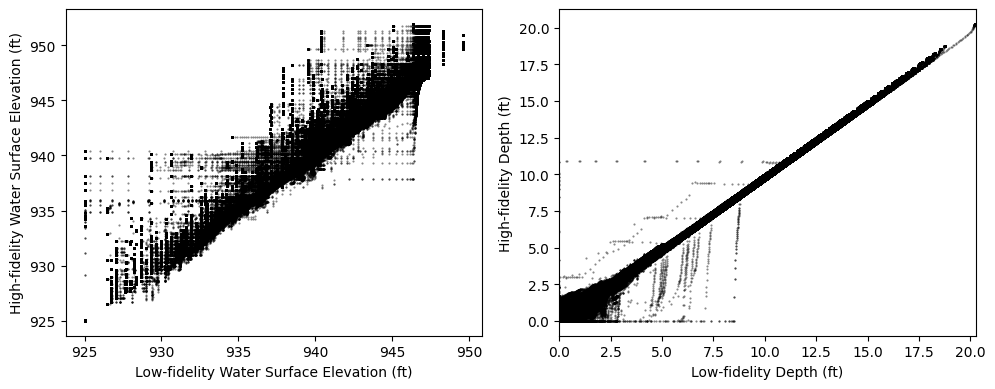

In [36]:
# EDA 1
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

axs[0].scatter(wsels_lf_flat, wsels_hf_flat, s=0.25, c='k', alpha=0.5)
axs[0].set_xlabel("Low-fidelity Water Surface Elevation (ft)")
axs[0].set_ylabel("High-fidelity Water Surface Elevation (ft)")

axs[1].scatter(depth_lf_flat, depth_hf_flat, s=0.25, c='k', alpha=0.5)
axs[1].set_xlabel("Low-fidelity Depth (ft)")
axs[1].set_ylabel("High-fidelity Depth (ft)")
axs[1].set_xlim(depth_hf_flat.min(), depth_hf_flat.max())

fig.tight_layout()

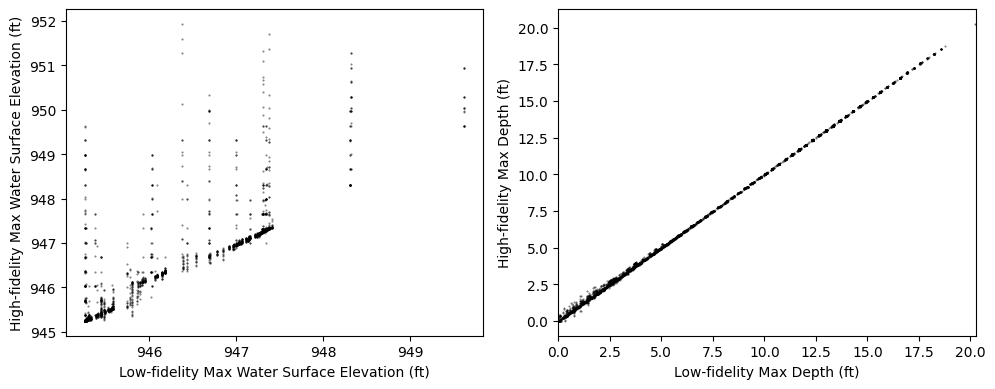

In [71]:
# EDA 2 (max wsel/depth)
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

axs[0].scatter(wsels_lf.max(axis=0).flatten(), wsels_hf.max(axis=0).flatten(), s=0.25, c='k', alpha=0.5)
axs[0].set_xlabel("Low-fidelity Max Water Surface Elevation (ft)")
axs[0].set_ylabel("High-fidelity Max Water Surface Elevation (ft)")

axs[1].scatter(depth_lf.max(axis=0).flatten(), depth_hf.max(axis=0).flatten(), s=0.25, c='k', alpha=0.5)
axs[1].set_xlabel("Low-fidelity Max Depth (ft)")
axs[1].set_ylabel("High-fidelity Max Depth (ft)")
axs[1].set_xlim(depth_hf.max(axis=0).min(), depth_hf.max(axis=0).max())

fig.tight_layout()

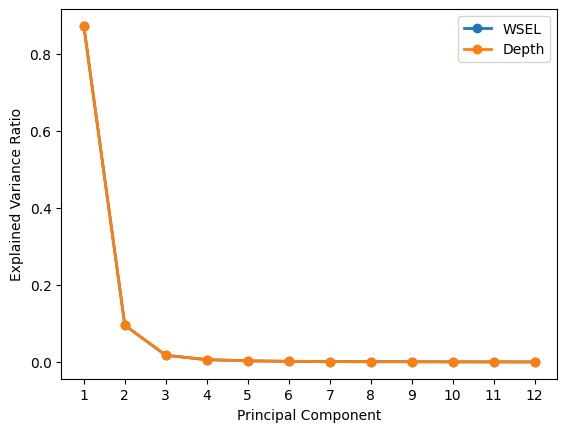

In [40]:
# Scree plot

# WSEL
pca_wsel = PCA(n_components=12)
pca_wsel.fit(wsels_hf_norm)
explained_variance_wsel = pca_wsel.explained_variance_ratio_

# Depth
pca_depth = PCA(n_components=12)
pca_depth.fit(depth_hf_norm)
explained_variance_depth = pca_depth.explained_variance_ratio_

# Plot Scree Plot
fig, ax = plt.subplots()
ax.plot(range(1, len(explained_variance_wsel) + 1), explained_variance_wsel, 'o-', linewidth=2, label="WSEL")
ax.plot(range(1, len(explained_variance_wsel) + 1), explained_variance_depth, 'o-', linewidth=2, label="Depth")
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_xticks(range(1, len(explained_variance_wsel) + 1))
ax.legend()

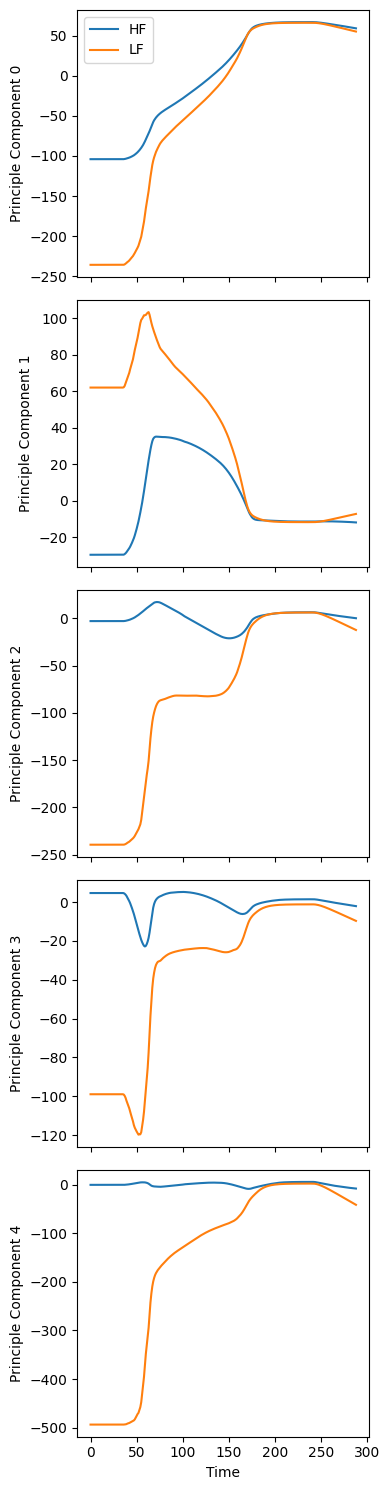

In [45]:
n_components=5
pca = PCA(n_components=n_components).fit(wsels_hf_norm)
hf_pcs = pca.transform(wsels_hf_norm)
lf_pcs = pca.transform(wsels_lf_norm)

fig, axs = plt.subplots(nrows=n_components, figsize=(4, 3*n_components), sharex=True)
for i in range(n_components):
    axs[i].plot(hf_pcs[:, i], label="HF")
    axs[i].plot(lf_pcs[:, i], label="LF")
    axs[i].set_ylabel(f"Principle Component {i}")
axs[-1].set_xlabel("Time")
axs[0].legend()
fig.tight_layout()

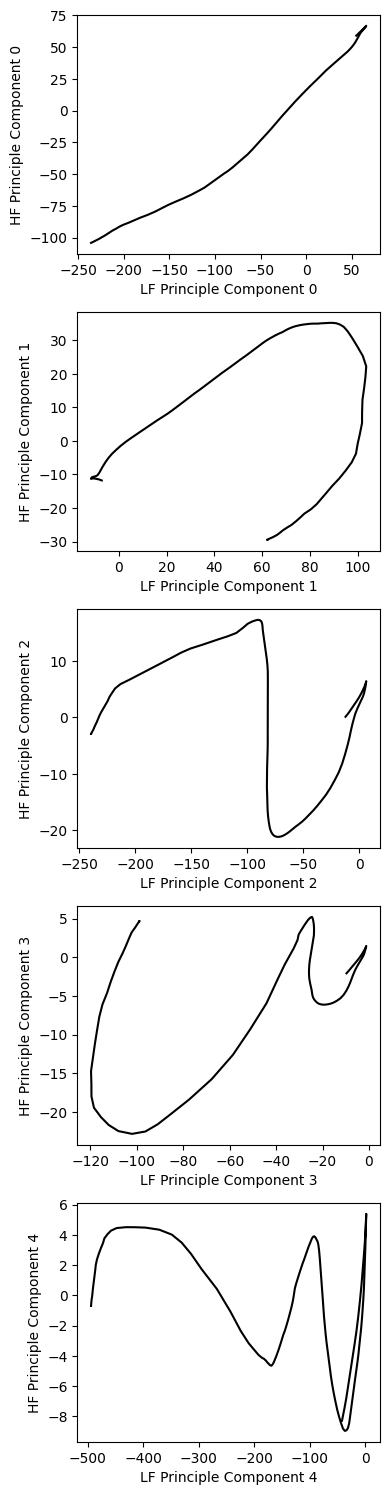

In [46]:
fig, axs = plt.subplots(nrows=n_components, figsize=(4, 3*n_components))
for i in range(n_components):
    axs[i].plot(lf_pcs[:, i], hf_pcs[:, i], c='k')
    axs[i].set_ylabel(f"HF Principle Component {i}")
    axs[i].set_xlabel(f"LF Principle Component {i}")
fig.tight_layout()

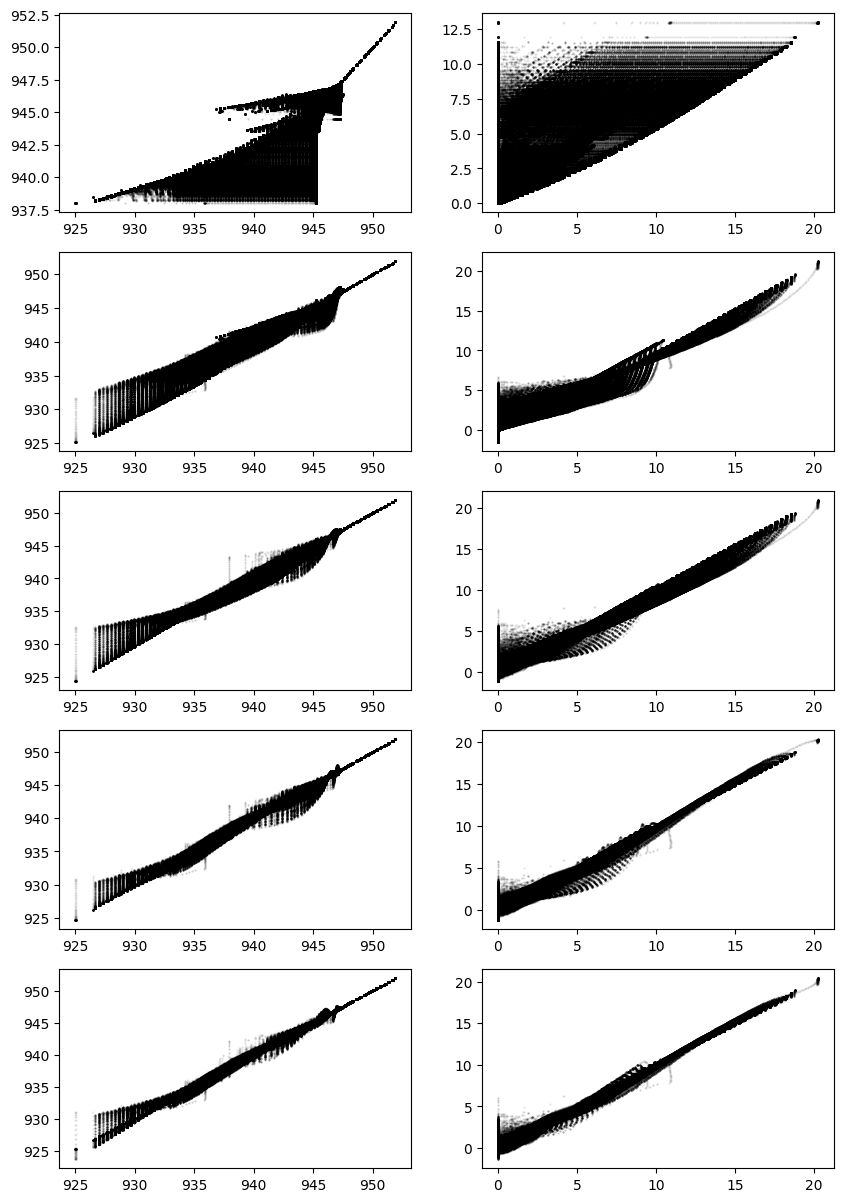

In [58]:
# Recreate data from PCA
fig, axs = plt.subplots(nrows=n_components, ncols=2, figsize=(10, 3*n_components))
for i in range(n_components):
    pca = PCA(n_components=i).fit(wsels_hf_norm)
    hf_pcs = pca.transform(wsels_hf_norm)
    back = pca.inverse_transform(hf_pcs)
    back = (back * std_wsel) + mean_wsel
    depth = back - el_hf

    axs[i, 0].scatter(wsels_hf_flat, back.flatten(), s=0.25, c='k', alpha=0.1)
    axs[i, 1].scatter(depth_hf_flat, depth.flatten(), s=0.25, c='k', alpha=0.1)

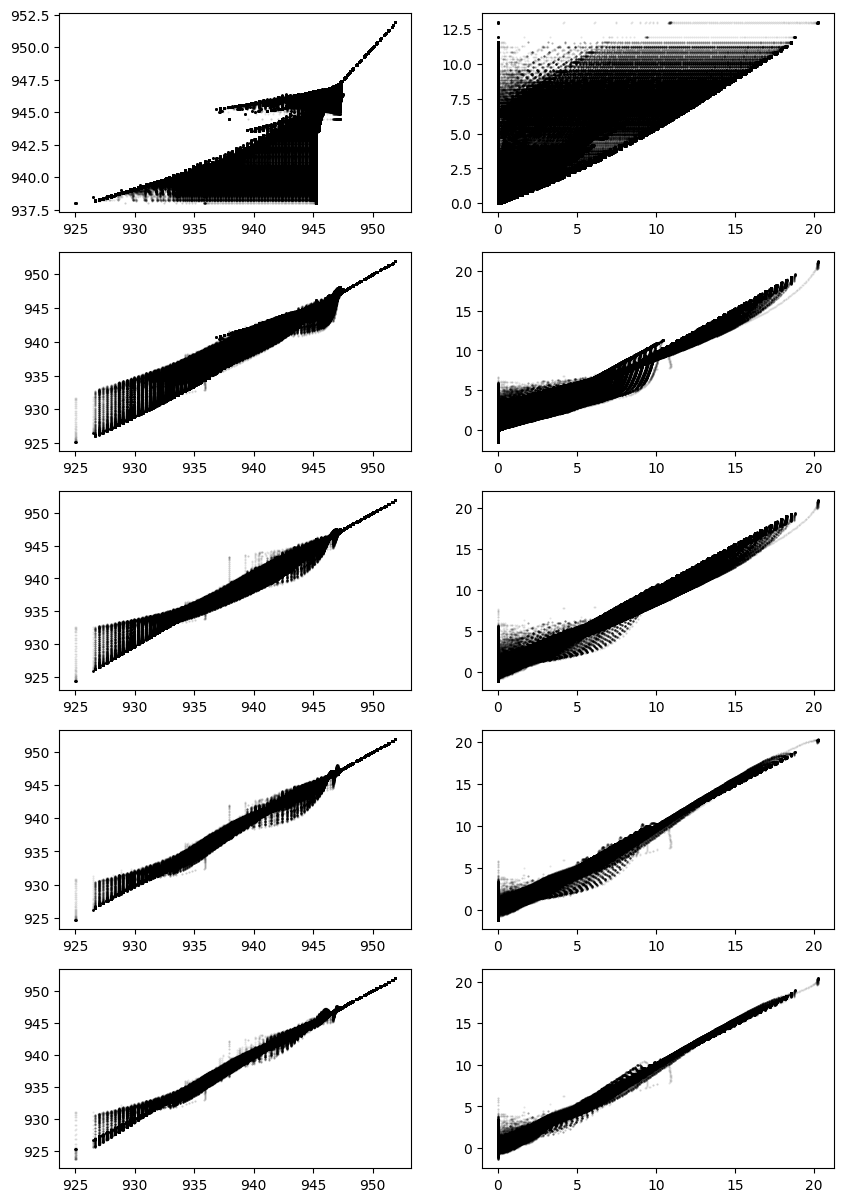

In [59]:
# Recreate data from PCA
fig, axs = plt.subplots(nrows=n_components, ncols=2, figsize=(10, 3*n_components))
for i in range(n_components):
    pca = PCA(n_components=i).fit(depth_hf_norm)
    hf_pcs = pca.transform(depth_hf_norm)
    back = pca.inverse_transform(hf_pcs)
    back = (back * std_depth) + mean_depth
    wsel = back + el_hf

    axs[i, 0].scatter(wsels_hf_flat, wsel.flatten(), s=0.25, c='k', alpha=0.1)
    axs[i, 1].scatter(depth_hf, back.flatten(), s=0.25, c='k', alpha=0.1)

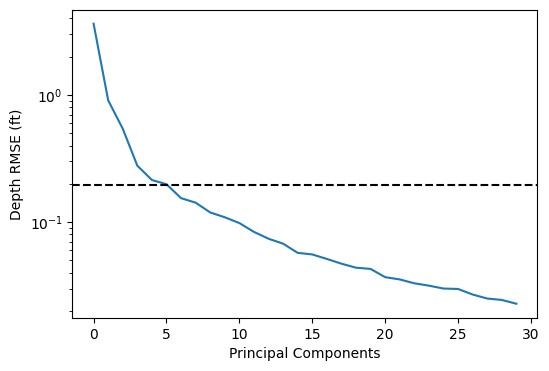

In [ ]:
rmses = []
components = [i for i in range(30)]
for i in components:
    pca = PCA(n_components=i).fit(wsels_hf_norm)
    hf_pcs = pca.transform(wsels_hf_norm)
    back = pca.inverse_transform(hf_pcs)
    back = (back * std_wsel) + mean_wsel
    depth = back - el_hf
    rmse = np.sqrt(((depth.flatten() - depth_hf_flat) ** 2).mean())
    rmses.append(rmse)

base_rmse = np.sqrt(((depth_lf_flat - depth_hf_flat) ** 2).mean())
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(components, rmses)
ax.axhline(base_rmse, ls="dashed", c="k")
ax.set_xlabel("Principal Components")
ax.set_ylabel("Depth RMSE (ft)")
ax.set_yscale("log")

In [ ]:
mesh_resampled.explore(column="cell_id_lf")
# mesh_hf.explore()

In [88]:
def save_numpy_as_gif(array, out_path, duration=100, loop=0):
    if array.ndim != 3:
        raise ValueError("Expected array of shape (num_frames, height, width)")
    if array.dtype != np.uint8:
        array_min = array.min()
        array_max = array.max()
        array = ((array - array_min) / (array_max - array_min) * 255).astype(np.uint8)

    frames = [Image.fromarray(frame, mode='L') for frame in array]

    frames[0].save(out_path, save_all=True, append_images=frames[1:], duration=duration, loop=loop)


In [ ]:
frames = []
for val in np.linspace(-400, 400, 100):
    point_in_pc_space = np.zeros(pca.n_components_)
    point_in_pc_space[0] = val
    recon = pca.inverse_transform(point_in_pc_space).reshape(w)
    frames.append(recon)
save_numpy_as_gif(np.array(frames), "pc1.gif")

ValueError: Expected array of shape (num_frames, height, width)